# Neuronales Netzwerk – MNIST 1

In [101]:
from tensorflow import keras
from keras.datasets import mnist
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 18.1
-------

In [102]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)
print(x_train[0].shape)


(60000, 28, 28)
(28, 28)


## 18.2
-------

In [103]:
df = pd.DataFrame(x_train.reshape(x_train.shape[0],x_train.shape[1] * x_train.shape[2])) #6000, 784
df.head(5)

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 18.3
-------

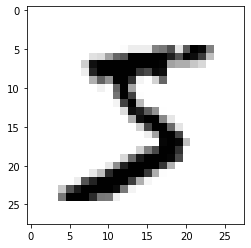

In [104]:
plt.imshow(x_train[0], cmap='gray_r')

## 18.4
-------

10 Knoten für 10 Werte

## 18.5
----

In [105]:
model = keras.Sequential()
model.add(keras.layers.Dense(64, activation="relu", input_shape=(784,)))
model.add(keras.layers.Dense(10, activation="softmax")) 
model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])

In [106]:
# Überblick über das Dataset
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                50240     
                                                                 
 dense_1 (Dense)             (None, 10)                650       
                                                                 
Total params: 50,890
Trainable params: 50,890
Non-trainable params: 0
_________________________________________________________________


In [107]:
x_train = x_train.reshape(x_train.shape[0],x_train.shape[1] * x_train.shape[2])
print(x_train.shape)

(60000, 784)


In [108]:
y_train = keras.utils.to_categorical(y_train, 10)
print(y_train.shape)

(60000, 10)


## 18.6
----

In [109]:
model.fit(x_train, y_train, epochs=5, batch_size=128)

Epoch 1/5
469/469 [==============================] - 1s 2ms/step - loss: 4.6043 - accuracy: 0.8158
Epoch 2/5
469/469 [==============================] - 1s 2ms/step - loss: 0.5477 - accuracy: 0.8905
Epoch 3/5
469/469 [==============================] - 1s 2ms/step - loss: 0.3964 - accuracy: 0.9216
Epoch 4/5
469/469 [==============================] - 1s 2ms/step - loss: 0.3251 - accuracy: 0.9358
Epoch 5/5
469/469 [==============================] - 1s 2ms/step - loss: 0.2793 - accuracy: 0.9442


In [110]:
x_test = x_test.reshape(x_test.shape[0],x_test.shape[1] * x_test.shape[2])
print(x_test.shape)

(10000, 784)


In [111]:
y_pred = model.predict(x_test)
y_pred[0]

313/313 [==============================] - 0s 893us/step


array([0.00000000e+00, 3.66854453e-34, 2.34289012e-11, 2.48227536e-08,
       0.00000000e+00, 1.28923256e-38, 0.00000000e+00, 1.00000000e+00,
       1.03361515e-29, 6.15525671e-15], dtype=float32)

In [112]:
y_test = keras.utils.to_categorical(y_test,10)
print(y_test.shape)

(10000, 10)


## 18.7
----

In [113]:
model.evaluate(x_test,y_test)

313/313 [==============================] - 0s 1ms/step - loss: 0.4567 - accuracy: 0.9309


[0.45672744512557983, 0.930899977684021]

# Neuronales Netzwerk – MNIST 2

In [114]:
model_history = model.fit(x_train, y_train, epochs=15, batch_size=128)
type(model_history.history)

Epoch 1/15
469/469 [==============================] - 1s 2ms/step - loss: 0.2434 - accuracy: 0.9500
Epoch 2/15
469/469 [==============================] - 1s 2ms/step - loss: 0.2225 - accuracy: 0.9560
Epoch 3/15
469/469 [==============================] - 1s 2ms/step - loss: 0.2032 - accuracy: 0.9582
Epoch 4/15
469/469 [==============================] - 1s 2ms/step - loss: 0.1887 - accuracy: 0.9602
Epoch 5/15
469/469 [==============================] - 1s 2ms/step - loss: 0.1854 - accuracy: 0.9621
Epoch 6/15
469/469 [==============================] - 1s 2ms/step - loss: 0.1774 - accuracy: 0.9648
Epoch 7/15
469/469 [==============================] - 1s 2ms/step - loss: 0.1672 - accuracy: 0.9654
Epoch 8/15
469/469 [==============================] - 1s 2ms/step - loss: 0.1632 - accuracy: 0.9675
Epoch 9/15
469/469 [==============================] - 1s 2ms/step - loss: 0.1567 - accuracy: 0.9685
Epoch 10/15
469/469 [==============================] - 1s 2ms/step - loss: 0.1428 - accuracy: 0.9702

dict

In [115]:
acc = model_history.history["accuracy"] 

In [116]:
type(acc)

list

In [117]:
len(acc)

15

## 18.2.1
----

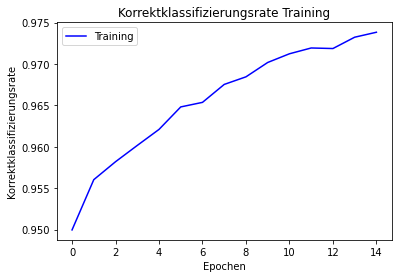

In [118]:
plt.plot(acc, 'b', label="Training") 
#plt.plot(range(len(acc)), acc, 'b', label="Training") #x values are optional but need to bee a range
plt.title("Korrektklassifizierungsrate Training") 
plt.xlabel("Epochen") 
plt.ylabel("Korrektklassifizierungsrate") 
plt.legend()
plt.show()

## 18.2.2
----

In [119]:
print(model_history.history.keys())

dict_keys(['loss', 'accuracy'])


In [120]:
model_history = model.fit(x_train, y_train, epochs=15, batch_size=128, validation_data=(x_test, y_test))

Epoch 1/15
469/469 [==============================] - 1s 2ms/step - loss: 0.1244 - accuracy: 0.9747 - val_loss: 0.5524 - val_accuracy: 0.9540
Epoch 2/15
469/469 [==============================] - 1s 2ms/step - loss: 0.1238 - accuracy: 0.9747 - val_loss: 0.5150 - val_accuracy: 0.9525
Epoch 3/15
469/469 [==============================] - 1s 2ms/step - loss: 0.1197 - accuracy: 0.9758 - val_loss: 0.5258 - val_accuracy: 0.9551
Epoch 4/15
469/469 [==============================] - 1s 2ms/step - loss: 0.1107 - accuracy: 0.9764 - val_loss: 0.5581 - val_accuracy: 0.9540
Epoch 5/15
469/469 [==============================] - 1s 2ms/step - loss: 0.1070 - accuracy: 0.9765 - val_loss: 0.5937 - val_accuracy: 0.9527
Epoch 6/15
469/469 [==============================] - 1s 2ms/step - loss: 0.1186 - accuracy: 0.9765 - val_loss: 0.5988 - val_accuracy: 0.9535
Epoch 7/15
469/469 [==============================] - 1s 2ms/step - loss: 0.1128 - accuracy: 0.9771 - val_loss: 0.6272 - val_accuracy: 0.9515
Epoch 

In [121]:
print(model_history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


In [122]:
acc = model_history.history["accuracy"] 
val_acc = model_history.history["val_accuracy"]
loss = model_history.history["loss"] 
val_loss = model_history.history["val_loss"]

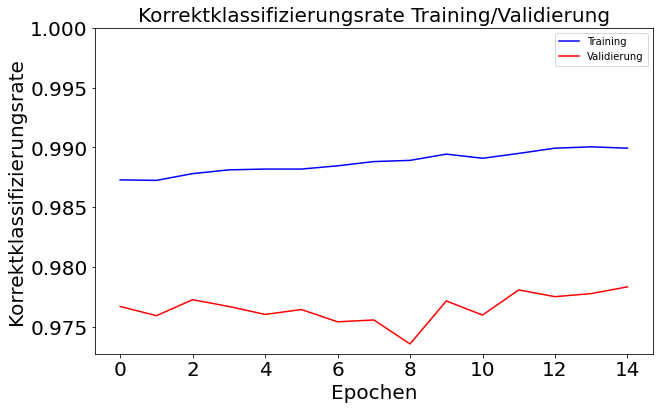

In [123]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))
ax.plot(np.sqrt(acc), 'b', label='Training')
ax.plot(np.sqrt(val_acc), 'r' ,label='Validierung')
plt.title("Korrektklassifizierungsrate Training/Validierung", fontsize=20) 
ax.set_xlabel(r'Epochen', fontsize=20)
ax.set_ylabel(r'Korrektklassifizierungsrate', fontsize=20)
plt.ylim(plt.ylim()[0],1)
ax.legend()
ax.tick_params(labelsize=20)

## 18.2.3
----

https://towardsdatascience.com/simple-guide-to-hyperparameter-tuning-in-neural-networks-3fe03dad8594

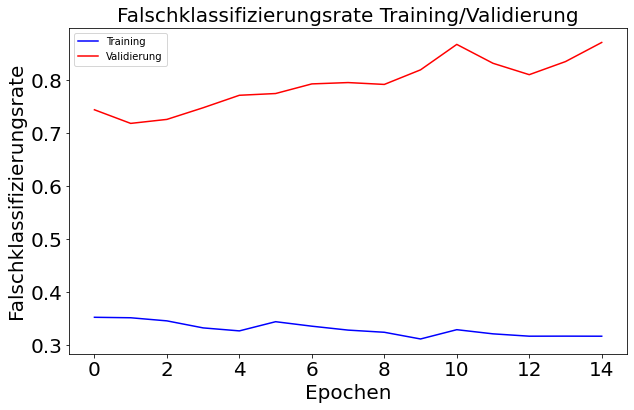

In [124]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))
ax.plot(np.sqrt(model_history.history['loss']), 'b', label='Training')
ax.plot(np.sqrt(model_history.history['val_loss']), 'r' ,label='Validierung')
plt.title("Falschklassifizierungsrate Training/Validierung", fontsize=20) 
ax.set_xlabel(r'Epochen', fontsize=20)
ax.set_ylabel(r'Falschklassifizierungsrate', fontsize=20)
ax.legend()
ax.tick_params(labelsize=20)

## 18.2.4
----

In [125]:
model.save('models')
keras.backend.clear_session()

INFO:tensorflow:Assets written to: models\assets


In [126]:
#loading the modal
#model = keras.models.load_model('models')

# Neuronales Netzwerk – MNIST 3

## 18.3.1
----

In [127]:
model = keras.models.load_model('models')
y_test.shape

(10000, 10)

In [128]:
testarg = np.argmax(y_test, axis=1)
y_pred = model.predict(x_test)
predarg = np.argmax(y_pred, axis=1)
pd.crosstab(testarg, predarg, rownames=['actual'], colnames=['pred'])

313/313 [==============================] - 0s 1ms/step


pred,0,1,2,3,4,5,6,7,8,9
actual,,,,,,,,,,
0,966,0,2,1,0,3,2,3,3,0
1,0,1120,2,4,0,3,1,2,3,0
2,6,2,973,11,4,1,4,12,18,1
3,1,0,10,954,2,11,0,5,14,13
4,1,2,2,0,947,0,8,5,6,11
5,4,3,1,14,3,851,6,1,7,2
6,7,3,1,0,7,10,926,0,4,0
7,3,5,8,4,2,4,0,978,5,19
8,4,4,9,11,12,10,4,4,909,7


## 18.3.2
----

In [129]:
nx_train = x_train/255
nx_test = x_test/255

In [136]:
model.fit(nx_train, y_train, epochs=5, batch_size=64, validation_data=(nx_test, y_test))

Epoch 1/5
938/938 [==============================] - 2s 2ms/step - loss: 0.0123 - accuracy: 0.9971 - val_loss: 0.1051 - val_accuracy: 0.9764
Epoch 2/5
938/938 [==============================] - 2s 2ms/step - loss: 0.0117 - accuracy: 0.9972 - val_loss: 0.1049 - val_accuracy: 0.9769
Epoch 3/5
938/938 [==============================] - 2s 2ms/step - loss: 0.0109 - accuracy: 0.9975 - val_loss: 0.1093 - val_accuracy: 0.9773
Epoch 4/5
938/938 [==============================] - 2s 2ms/step - loss: 0.0102 - accuracy: 0.9975 - val_loss: 0.1140 - val_accuracy: 0.9769
Epoch 5/5
938/938 [==============================] - 2s 2ms/step - loss: 0.0097 - accuracy: 0.9977 - val_loss: 0.1147 - val_accuracy: 0.9763


In [137]:
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/5
938/938 [==============================] - 2s 2ms/step - loss: 1.2999 - accuracy: 0.9973 - val_loss: 27.1277 - val_accuracy: 0.9741
Epoch 2/5
938/938 [==============================] - 2s 2ms/step - loss: 0.9711 - accuracy: 0.9977 - val_loss: 28.0960 - val_accuracy: 0.9744
Epoch 3/5
938/938 [==============================] - 2s 2ms/step - loss: 0.7792 - accuracy: 0.9977 - val_loss: 27.1405 - val_accuracy: 0.9744
Epoch 4/5
938/938 [==============================] - 2s 2ms/step - loss: 0.7396 - accuracy: 0.9977 - val_loss: 27.3659 - val_accuracy: 0.9733
Epoch 5/5
938/938 [==============================] - 2s 2ms/step - loss: 0.6602 - accuracy: 0.9982 - val_loss: 26.9574 - val_accuracy: 0.9738


## 18.3.3
----

### Epochs 15 | Batchsize 128
loss: 23.6948 - accuracy: 0.9749

### Epochs 5 | Batchsize 128
loss: 26.7148 - accuracy: 0.9750

### Epochs 5 | Batchsize 64
loss: 34.8354 - accuracy: 0.9714

### Epochs 10 | Batchsize 64
loss: 41.7956 - accuracy: 0.9757

### Epochs 10 | Batchsize 128
loss: 48.1233 - accuracy: 0.9748

### Epochs 10 | Batchsize 128
loss: 48.1233 - accuracy: 0.9748

### Epochs 5 | Batchsize 128
loss: 52.2292 - accuracy: 0.9743

## 18.3.4
----

In [132]:
model.save('model_minst3')
#model = keras.models.load_model('model_minst3')

INFO:tensorflow:Assets written to: model_minst3\assets


# Neuronales Netzwerk – MNIST 4

## 18.3.3
----

In [133]:
model = keras.models.load_model('model_minst3')
model.fit(nx_train, y_train, epochs=15, batch_size=128, validation_data=(nx_test, y_test))

Epoch 1/15
469/469 [==============================] - 2s 3ms/step - loss: 0.0493 - accuracy: 0.9872 - val_loss: 0.0780 - val_accuracy: 0.9759
Epoch 2/15
469/469 [==============================] - 1s 2ms/step - loss: 0.0402 - accuracy: 0.9887 - val_loss: 0.0780 - val_accuracy: 0.9768
Epoch 3/15
469/469 [==============================] - 1s 2ms/step - loss: 0.0356 - accuracy: 0.9904 - val_loss: 0.0749 - val_accuracy: 0.9776
Epoch 4/15
469/469 [==============================] - 1s 2ms/step - loss: 0.0319 - accuracy: 0.9914 - val_loss: 0.0777 - val_accuracy: 0.9767
Epoch 5/15
469/469 [==============================] - 1s 2ms/step - loss: 0.0289 - accuracy: 0.9927 - val_loss: 0.0779 - val_accuracy: 0.9775
Epoch 6/15
469/469 [==============================] - 1s 2ms/step - loss: 0.0261 - accuracy: 0.9933 - val_loss: 0.0786 - val_accuracy: 0.9773
Epoch 7/15
469/469 [==============================] - 1s 2ms/step - loss: 0.0239 - accuracy: 0.9939 - val_loss: 0.0811 - val_accuracy: 0.9781
Epoch 

In [134]:
from PIL import Image

def prepareimage(number):
    img = Image.open(number + ".png").convert("L") 
    img = np.array(img) 
    img = img.reshape((1, 784))
    img = img/255
    return img

In [135]:
prediction = model.predict(prepareimage("0"))
print(np.argmax(prediction, axis=1))

prediction = model.predict(prepareimage("1"))
print(np.argmax(prediction, axis=1))

prediction = model.predict(prepareimage("2"))
print(np.argmax(prediction, axis=1))

1/1 [==============================] - 0s 45ms/step
[9]
1/1 [==============================] - 0s 17ms/step
[8]
1/1 [==============================] - 0s 18ms/step
[2]
